# Task 4: Data Merging and Advanced Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"

state_txn_users = pd.read_excel(file_path, sheet_name="State_Txn and Users")
state_device = pd.read_excel(file_path, sheet_name="State_DeviceData")
district_txn_users = pd.read_excel(file_path, sheet_name="District_Txn and Users")
district_demo = pd.read_excel(file_path, sheet_name="District Demographics")

print("Datasets loaded successfully!")

Datasets loaded successfully!


## Task 4.1: Ratio of users to population by state

In [4]:
state_users = (
    state_txn_users
    .groupby("State")["Registered Users"]
    .sum()
    .reset_index()
)

state_population = (
    district_demo
    .groupby("State")["Population"]
    .sum()
    .reset_index()
)   
 # Aggregate State Users and Population

In [6]:
user_population_ratio = pd.merge(
    state_users,
    state_population,
    on="State",
    how="inner"
)

user_population_ratio["User_Population_Ratio"] = (
    user_population_ratio["Registered Users"] / user_population_ratio["Population"]
)

user_population_ratio = user_population_ratio.sort_values(
    by="User_Population_Ratio",
    ascending=False
)

user_population_ratio   # Merge and Calculate Ratio

,State,Registered Users,Population,User_Population_Ratio
8,Delhi,95374654,16787941,5.681141
7,Dadra & Nagar Haveli and Daman & Diu,2701112,586956,4.601899
31,Telangana,149224214,36366570,4.103335
5,Chandigarh,3801466,1055450,3.601749
15,Karnataka,203098564,60965960,3.331344
11,Haryana,85564119,25855357,3.309338
9,Goa,4755320,1457723,3.262156
1,Andhra Pradesh,158007957,49378776,3.199916
20,Maharashtra,315783658,112378989,2.809988
34,Uttarakhand,23792747,10116752,2.351817


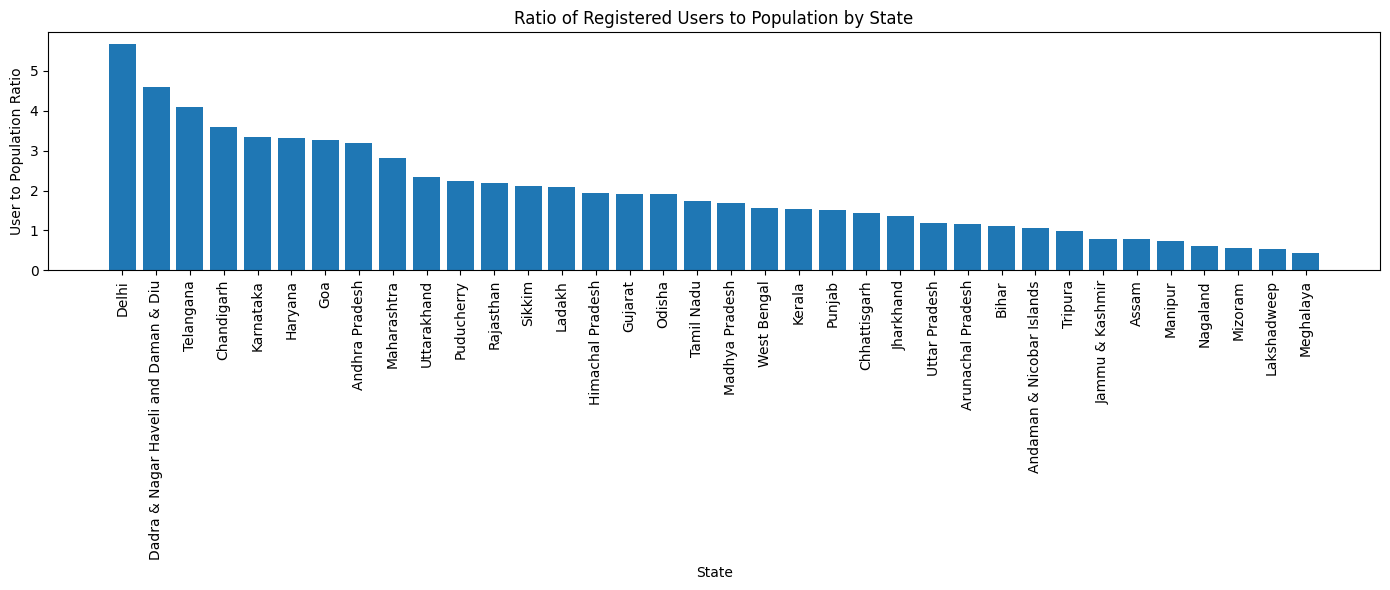

In [8]:
plt.figure(figsize=(14, 6))

plt.bar(
    user_population_ratio["State"],
    user_population_ratio["User_Population_Ratio"]
)

plt.xticks(rotation=90)
plt.title("Ratio of Registered Users to Population by State")
plt.xlabel("State")
plt.ylabel("User to Population Ratio")
plt.tight_layout()
plt.show()

## Task 4.2: Correlate population density with transaction volume

In [9]:
district_transactions = (
    district_txn_users
    .groupby(["State", "District"])["Transactions"]
    .sum()
    .reset_index()
)

In [10]:
district_merged = pd.merge(
    district_transactions,
    district_demo[["State", "District", "Density"]],
    on=["State", "District"],
    how="inner"
)

district_merged.head()

,State,District,Transactions,Density
0,Andaman & Nicobar Islands,South Andaman,1014784,89
1,Andhra Pradesh,Anantapur,124411535,213
2,Andhra Pradesh,Chittoor,181284289,275
3,Andhra Pradesh,East Godavari,160754836,477
4,Andhra Pradesh,Guntur,160872479,429


In [11]:
correlation = district_merged["Density"].corr(district_merged["Transactions"])

print("Correlation between population density and transaction volume:", correlation)

Correlation between population density and transaction volume: 0.4188041949959691


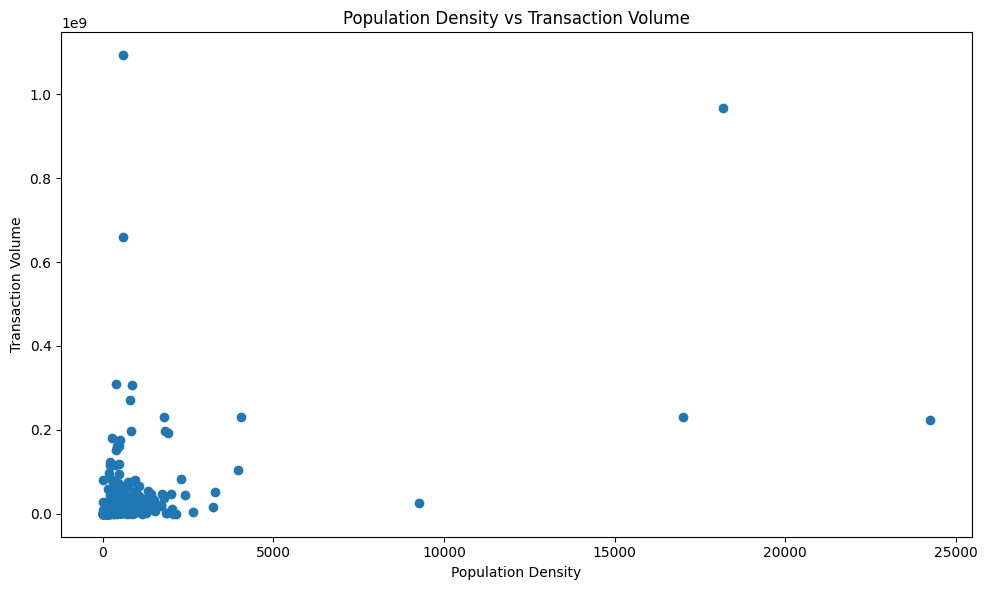

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    district_merged["Density"],
    district_merged["Transactions"]
)

plt.title("Population Density vs Transaction Volume")
plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.tight_layout()
plt.show()

## Task 4.3: Average transaction amount per user

In [13]:
state_amount_user = (
    state_txn_users
    .groupby("State")[["Amount (INR)", "Registered Users"]]
    .sum()
    .reset_index()
)

state_amount_user["Average_Transaction_Amount_Per_User"] = (
    state_amount_user["Amount (INR)"] / state_amount_user["Registered Users"]
)

state_amount_user = state_amount_user.sort_values(
    by="Average_Transaction_Amount_Per_User",
    ascending=False
)

state_amount_user

,State,Amount (INR),Registered Users,Average_Transaction_Amount_Per_User
31,Telangana,4.574246e+12,149224214,30653.509622
15,Karnataka,4.361396e+12,203098564,21474.282206
1,Andhra Pradesh,3.187847e+12,158007957,20175.233763
28,Rajasthan,2.625584e+12,149770064,17530.768707
8,Delhi,1.649942e+12,95374654,17299.587909
21,Manipur,3.579325e+10,2317734,15443.209245
19,Madhya Pradesh,1.915101e+12,125339823,15279.269764
25,Odisha,1.220615e+12,80404103,15180.998375
4,Bihar,1.639579e+12,115284760,14221.991933
5,Chandigarh,5.371208e+10,3801466,14129.308175


In [15]:
state_amount_user.head(5)

,State,Amount (INR),Registered Users,Average_Transaction_Amount_Per_User
31,Telangana,4.574246e+12,149224214,30653.509622
15,Karnataka,4.361396e+12,203098564,21474.282206
1,Andhra Pradesh,3.187847e+12,158007957,20175.233763
28,Rajasthan,2.625584e+12,149770064,17530.768707
8,Delhi,1.649942e+12,95374654,17299.587909


In [16]:
state_amount_user.tail(5)

,State,Amount (INR),Registered Users,Average_Transaction_Amount_Per_User
12,Himachal Pradesh,9.786546e+10,13373980,7317.601442
16,Kerala,3.729599e+11,51267042,7274.846690
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
32,Tripura,2.097051e+10,3661575,5727.184275
18,Lakshadweep,1.921587e+08,34223,5614.898889


In [17]:
state_amount_user.sort_values(
    by="Average_Transaction_Amount_Per_User",
    ascending=True
).head(5)

,State,Amount (INR),Registered Users,Average_Transaction_Amount_Per_User
18,Lakshadweep,1.921587e+08,34223,5614.898889
32,Tripura,2.097051e+10,3661575,5727.184275
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
16,Kerala,3.729599e+11,51267042,7274.846690
12,Himachal Pradesh,9.786546e+10,13373980,7317.601442


## Task 4.4: Device brand usage ratio

In [18]:
brand_users = (
    state_device
    .groupby(["State", "Brand"])["Registered Users"]
    .sum()
    .reset_index()
)

total_state_users = (
    state_txn_users
    .groupby("State")["Registered Users"]
    .sum()
    .reset_index()
)

In [19]:
brand_usage_ratio = pd.merge(
    brand_users,
    total_state_users,
    on="State",
    how="inner",
    suffixes=("_Brand", "_Total")
)

brand_usage_ratio["Usage_Ratio"] = (
    brand_usage_ratio["Registered Users_Brand"] / brand_usage_ratio["Registered Users_Total"]
)

brand_usage_ratio = brand_usage_ratio.sort_values(
    by=["State", "Usage_Ratio"],
    ascending=[True, False]
)

brand_usage_ratio.head(10)

,State,Brand,Registered Users_Brand,Registered Users_Total,Usage_Ratio
11,Andaman & Nicobar Islands,Xiaomi,97889,408396,0.239691
10,Andaman & Nicobar Islands,Vivo,88408,408396,0.216476
8,Andaman & Nicobar Islands,Samsung,77065,408396,0.188702
5,Andaman & Nicobar Islands,Oppo,36007,408396,0.088167
6,Andaman & Nicobar Islands,Others,33630,408396,0.082347
7,Andaman & Nicobar Islands,Realme,22546,408396,0.055206
4,Andaman & Nicobar Islands,OnePlus,15397,408396,0.037701
1,Andaman & Nicobar Islands,Huawei,11497,408396,0.028152
3,Andaman & Nicobar Islands,Motorola,9491,408396,0.023240
0,Andaman & Nicobar Islands,Apple,9334,408396,0.022855


In [20]:
brand_usage_ratio[
    ["State", "Brand", "Registered Users_Brand", "Registered Users_Total", "Usage_Ratio"]
]

,State,Brand,Registered Users_Brand,Registered Users_Total,Usage_Ratio
11,Andaman & Nicobar Islands,Xiaomi,97889,408396,0.239691
10,Andaman & Nicobar Islands,Vivo,88408,408396,0.216476
8,Andaman & Nicobar Islands,Samsung,77065,408396,0.188702
5,Andaman & Nicobar Islands,Oppo,36007,408396,0.088167
6,Andaman & Nicobar Islands,Others,33630,408396,0.082347
...,...,...,...,...,...
436,West Bengal,Asus,2775479,144242183,0.019242
438,West Bengal,Huawei,2239841,144242183,0.015528
440,West Bengal,Micromax,1981032,144242183,0.013734
437,West Bengal,Gionee,206751,144242183,0.001433


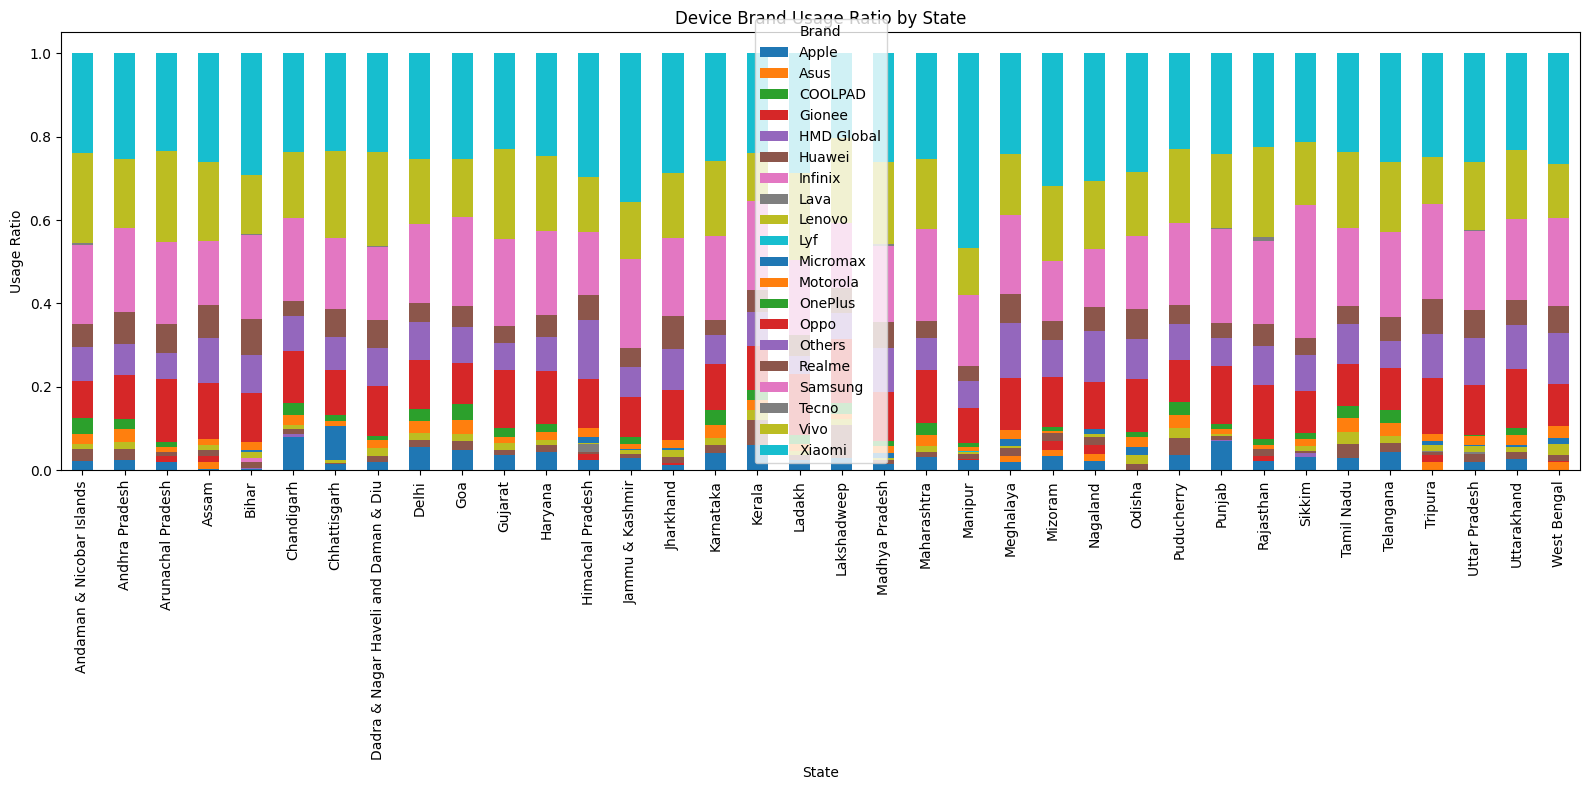

In [21]:
brand_pivot = brand_usage_ratio.pivot(
    index="State",
    columns="Brand",
    values="Usage_Ratio"
).fillna(0)

brand_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8)
)

plt.title("Device Brand Usage Ratio by State")
plt.xlabel("State")
plt.ylabel("Usage Ratio")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Conclusion

Task 4 completed successfully.

- Calculated user-to-population ratio by state.
- Found correlation between density and transaction volume.
- Calculated average transaction amount per user.
- Computed device brand usage ratio.
- Created charts for visual interpretation.